In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PATH1_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA55raw.TL319_t232.time_varying_COBESST/cpl/hist/'
PATH2_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA.TL319_t232.time_varying_COBESST/cpl/hist/'
PATH3_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_ERA5.TL319_t232.2001_2010_test/cpl/hist/'

filename1_raw = 'a.e30.A_JRA55raw.TL319_t232.time_varying_COBESST.cpl.hi.1959-12-31-64800.nc'
filename2_raw = 'a.e30.A_JRA.TL319_t232.time_varying_COBESST.cpl.hi.2010-01-01-00000.nc'
filename3_raw = 'a.e30.A_ERA5.TL319_t232.2001_2010_test.cpl.hi.2011-01-01-00000.nc'

area1_raw = xr.open_dataset(PATH1_raw + filename1_raw, engine="netcdf4")['MED_ocn_area'].isel(time=0)
area2_raw = xr.open_dataset(PATH2_raw + filename2_raw, engine="netcdf4")['MED_ocn_area'].isel(time=0)
area3_raw = xr.open_dataset(PATH3_raw + filename3_raw, engine="netcdf4")['MED_ocn_area'].isel(time=0)

mask1 = xr.open_dataset(PATH1_raw + filename1_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})
mask2 = xr.open_dataset(PATH2_raw + filename2_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})
mask3 = xr.open_dataset(PATH3_raw + filename3_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})

mask1 = mask1.where(mask1 != 0, np.nan)
mask2 = mask2.where(mask2 != 0, np.nan)
mask3 = mask3.where(mask3 != 0, np.nan)

In [3]:
R2 = 6371e3**2
area1 = (area1_raw*R2).rename({"MED_ocn_ny": "y", "MED_ocn_nx": "x"})
area2 = (area2_raw*R2).rename({"MED_ocn_ny": "y", "MED_ocn_nx": "x"})
area3 = (area3_raw*R2).rename({"MED_ocn_ny": "y", "MED_ocn_nx": "x"})

weights1 = ((mask1 * area1)/np.sum(area1*mask1))
weights1 = weights1.fillna(0)

weights2 = ((mask2 * area2)/np.sum(area2*mask2))
weights2 = weights2.fillna(0)

weights3 = ((mask3 * area3)/np.sum(area3*mask3))
weights3 = weights3.fillna(0)

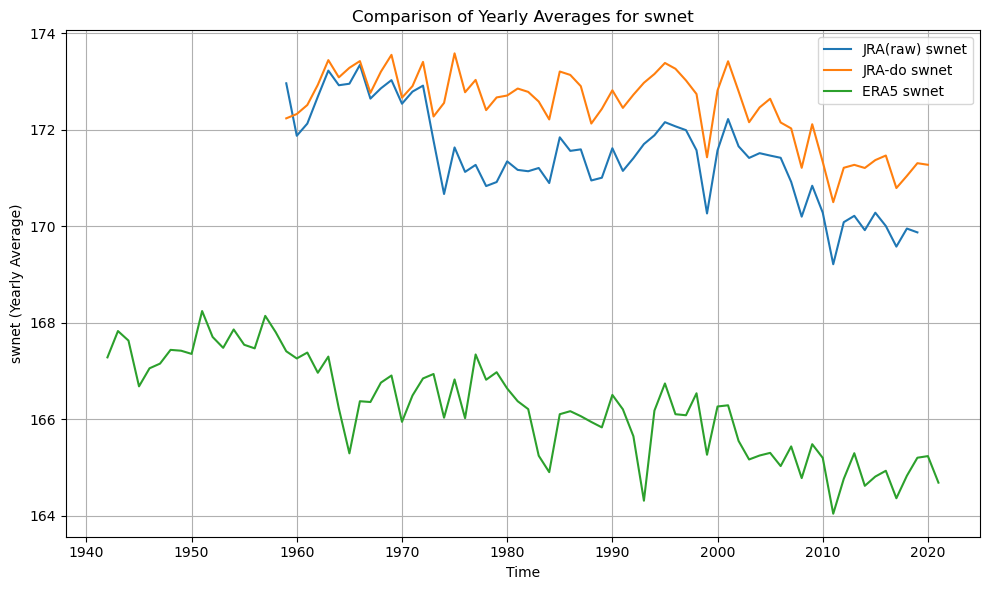

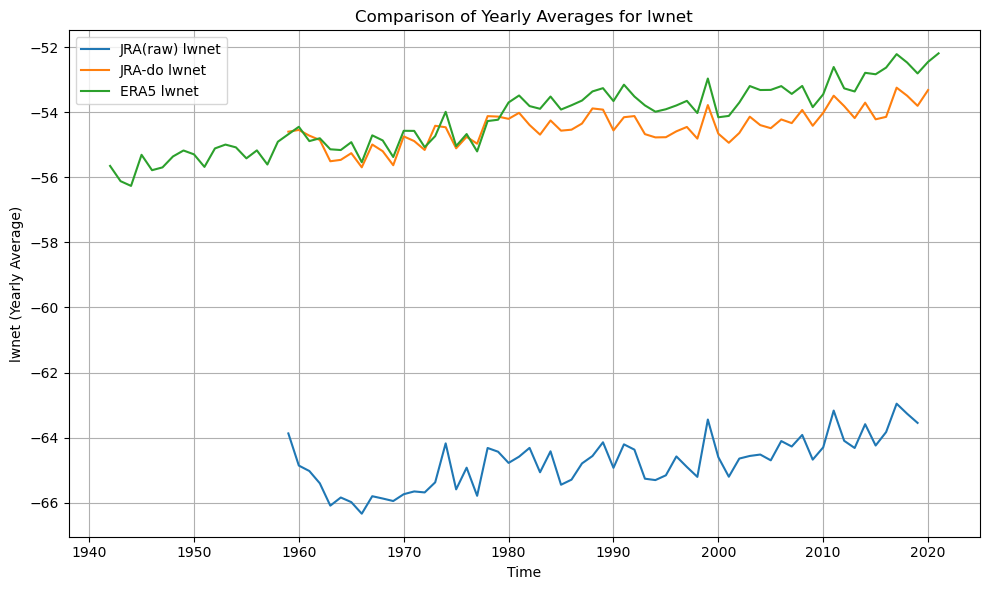

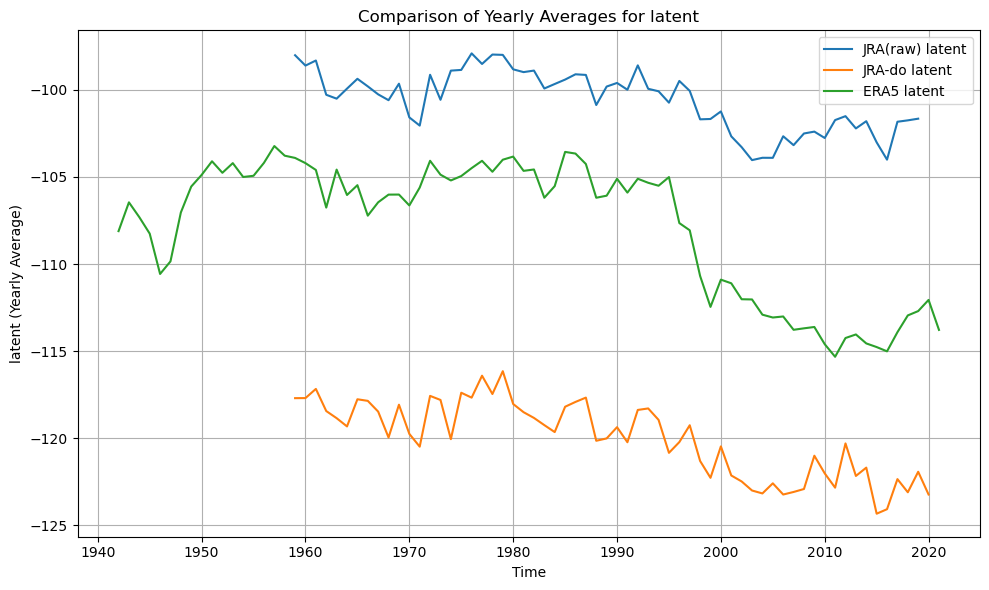

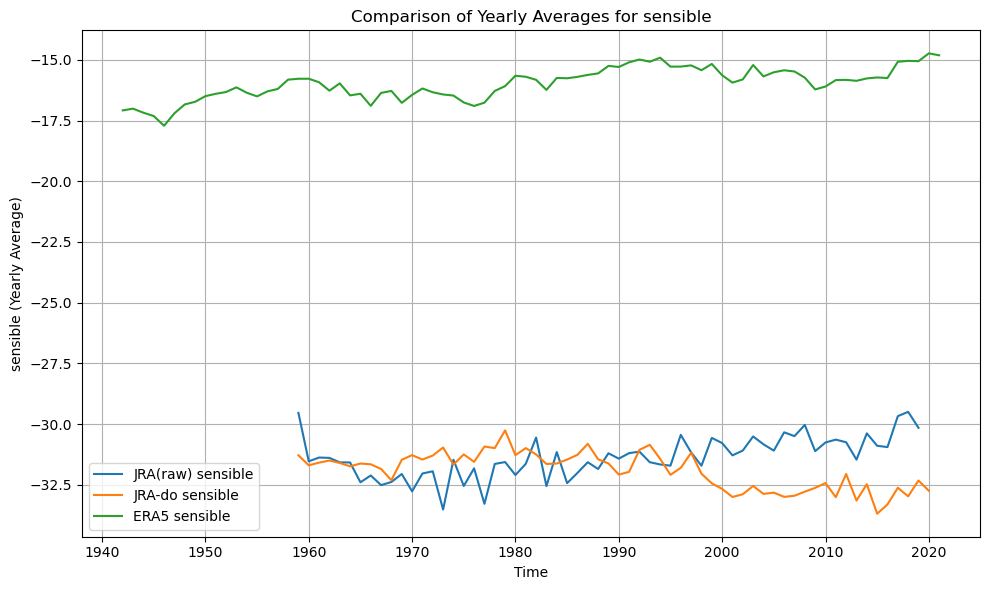

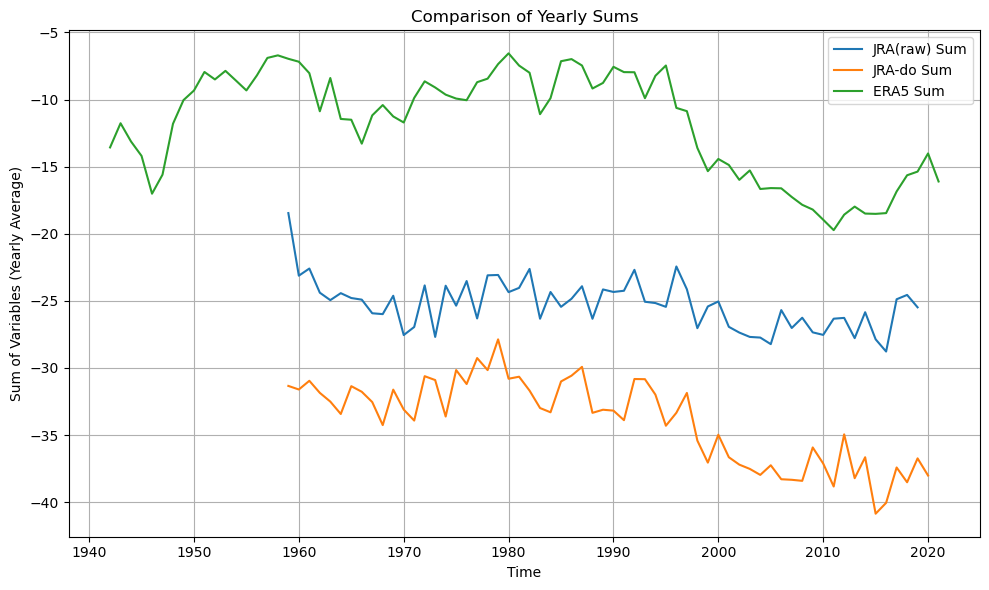

CPU times: user 1min 10s, sys: 4min 1s, total: 5min 11s
Wall time: 24min 55s


In [5]:
%%time

PATH1 = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.time_varying_COBESST/MONTHLY/" 
PATH2 = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.time_varying_COBESST/MONTHLY/"  
PATH3 = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232_all/MONTHLY/"  


file_names1 = {
    "swnet": "swnet_1958_2018.nc",
    "lwnet": "lwnet_1958_2018.nc",
    "latent": "latent_1958_2018.nc",
    "sensible": "sensible_1958_2018.nc",
}

file_names2 = {
    "swnet": "swnet_1958_2019.nc",
    "lwnet": "lwnet_1958_2019.nc",
    "latent": "latent_1958_2019.nc",
    "sensible": "sensible_1958_2019.nc",
}

file_names3 = {
    "swnet": "swnet_1941_2020.nc",
    "lwnet": "lwnet_1941_2020.nc",
    "latent": "latent_1941_2020.nc",
    "sensible": "sensible_1941_2020.nc",
}


def process_dataset(path, file_names, weights, variable_names):
    yearly_means = {}
    for key, file_name in file_names.items():
        ds = xr.open_dataset(path + file_name, engine="netcdf4")
        var_name = variable_names[key]
        var_time_series = ds[var_name].weighted(weights).mean(dim=["x", "y"])
        var_time_series["time"] = pd.to_datetime([t.strftime('%Y-%m-%d') for t in var_time_series["time"].values])
        yearly_mean = var_time_series.resample(time="1YE").mean()
        yearly_means[key] = yearly_mean
    yearly_means["sum"] = sum(yearly_means.values())
    return yearly_means



variable_names = {
    "swnet": "ocnExp_Foxx_swnet",
    "lwnet": "ocnExp_Foxx_lwnet",
    "latent": "ocnExp_Foxx_lat",
    "sensible": "ocnExp_Foxx_sen",
}

# Process all datasets
yearly_means1 = process_dataset(PATH1, file_names1, weights1,  variable_names)
yearly_means2 = process_dataset(PATH2, file_names2, weights2, variable_names)
yearly_means3 = process_dataset(PATH3, file_names3, weights3, variable_names)

# Plot comparison for each variable
for key in file_names2.keys():
    plt.figure(figsize=(10, 6))
    plt.plot(yearly_means1[key]["time"], yearly_means1[key], label=f"JRA(raw) {key}")
    plt.plot(yearly_means2[key]["time"], yearly_means2[key], label=f"JRA-do {key}")
    plt.plot(yearly_means3[key]["time"], yearly_means3[key], label=f"ERA5 {key}")
    plt.xlabel("Time")
    plt.ylabel(f"{key} (Yearly Average)")
    plt.title(f"Comparison of Yearly Averages for {key}")
    # plt.xlim(1940,2020) 
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# Plot comparison for the sum of variables
plt.figure(figsize=(10, 6))
plt.plot(yearly_means1["sum"]["time"], yearly_means1["sum"], label="JRA(raw) Sum")
plt.plot(yearly_means2["sum"]["time"], yearly_means2["sum"], label="JRA-do Sum")
plt.plot(yearly_means3["sum"]["time"], yearly_means3["sum"], label="ERA5 Sum")
plt.xlabel("Time")
# plt.xlim(1940, 2020) 
plt.ylabel("Sum of Variables (Yearly Average)")
plt.title("Comparison of Yearly Sums")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()